# **Import library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Theme**

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# **Data Inspection**

In [4]:
print("=== 1. DATA INSPECTION ===")
df = pd.read_csv('car_data.csv')

print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

=== 1. DATA INSPECTION ===
Dataset Shape: (4345, 8)

Data Types:
name              object
year             float64
selling_price    float64
km_driven         object
fuel              object
seller_type       object
transmission      object
owner             object
dtype: object

Missing Values:
name             328
year             304
selling_price    291
km_driven        319
fuel             303
seller_type      289
transmission     305
owner            286
dtype: int64

Duplicate Rows: 112


# **Data Cleaning**

In [5]:
print("\n=== 2. DATA CLEANING ===")

# Drop exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Standardize categorical typos
fuel_typos = {
    'Petrrol': 'Petrol', 'Petorl': 'Petrol', 'Petrl': 'Petrol',
    'Deisel': 'Diesel', 'Diesl': 'Diesel'
}
seller_typos = {
    'Indvidual': 'Individual', 'Indivudal': 'Individual',
    'Deelar': 'Dealer', 'Dealerr': 'Dealer'
}

df['fuel'] = df['fuel'].replace(fuel_typos)
df['seller_type'] = df['seller_type'].replace(seller_typos)

# Clean km_driven column
def clean_km_driven(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().replace('km', '').replace('k', '000').replace('abc', '').replace('unknown', '').strip()
    try:
        res = float(val_str)
        return res if res > 0 else np.nan
    except ValueError:
        return np.nan

df['km_driven'] = df['km_driven'].apply(clean_km_driven)

# Remove invalid outliers in year and price
df.loc[(df['year'] < 1990) | (df['year'] > 2026), 'year'] = np.nan
df.loc[df['selling_price'] <= 0, 'selling_price'] = np.nan

# Extract brand for intelligent imputation
df['brand'] = df['name'].dropna().apply(lambda x: str(x).split()[0])

# Impute missing values
for col in ['year', 'selling_price', 'km_driven']:
    df[col] = df.groupby('brand')[col].transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else df[col].median()))
    df[col] = df[col].fillna(df[col].median())

for cat_col in ['fuel', 'seller_type', 'transmission', 'owner']:
    df[cat_col] = df[cat_col].fillna(df[cat_col].mode()[0])

print("Missing values after cleaning:\n", df.isnull().sum())


=== 2. DATA CLEANING ===
Missing values after cleaning:
 name             326
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
brand            326
dtype: int64


# **Feature Engineering**

In [6]:
print("\n=== 3. FEATURE ENGINEERING ===")

df['car_age'] = 2026 - df['year']
df['km_per_year'] = df['km_driven'] / (df['car_age'] + 1)
df['price_category'] = pd.qcut(df['selling_price'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])

print(df[['name', 'brand', 'car_age', 'km_per_year', 'price_category']].head())

# Save cleaned dataset for the dashboard
df.to_csv('cleaned_car_data.csv', index=False)
print("\nCleaned dataset saved to 'cleaned_car_data.csv'")


=== 3. FEATURE ENGINEERING ===
                       name    brand  car_age   km_per_year price_category
0             Maruti 800 AC   Maruti     19.0   3500.000000         Budget
1  Maruti Wagon R LXI Minor   Maruti     12.0   3846.153846         Budget
2      Hyundai Verna 1.6 SX  Hyundai     14.0   6666.666667         Luxury
3    Datsun RediGO T Option   Datsun      9.0   4600.000000         Budget
4     Honda Amaze VX i-DTEC    Honda     12.0  10846.153846      Mid-Range

Cleaned dataset saved to 'cleaned_car_data.csv'


# **Univariate Analysis**



=== 4. UNIVARIATE ANALYSIS ===


/tmp/ipykernel_3388/1780239424.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fuel', data=df, ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_3388/1780239424.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='seller_type', data=df, ax=axes[1, 1], palette='Greens_r')


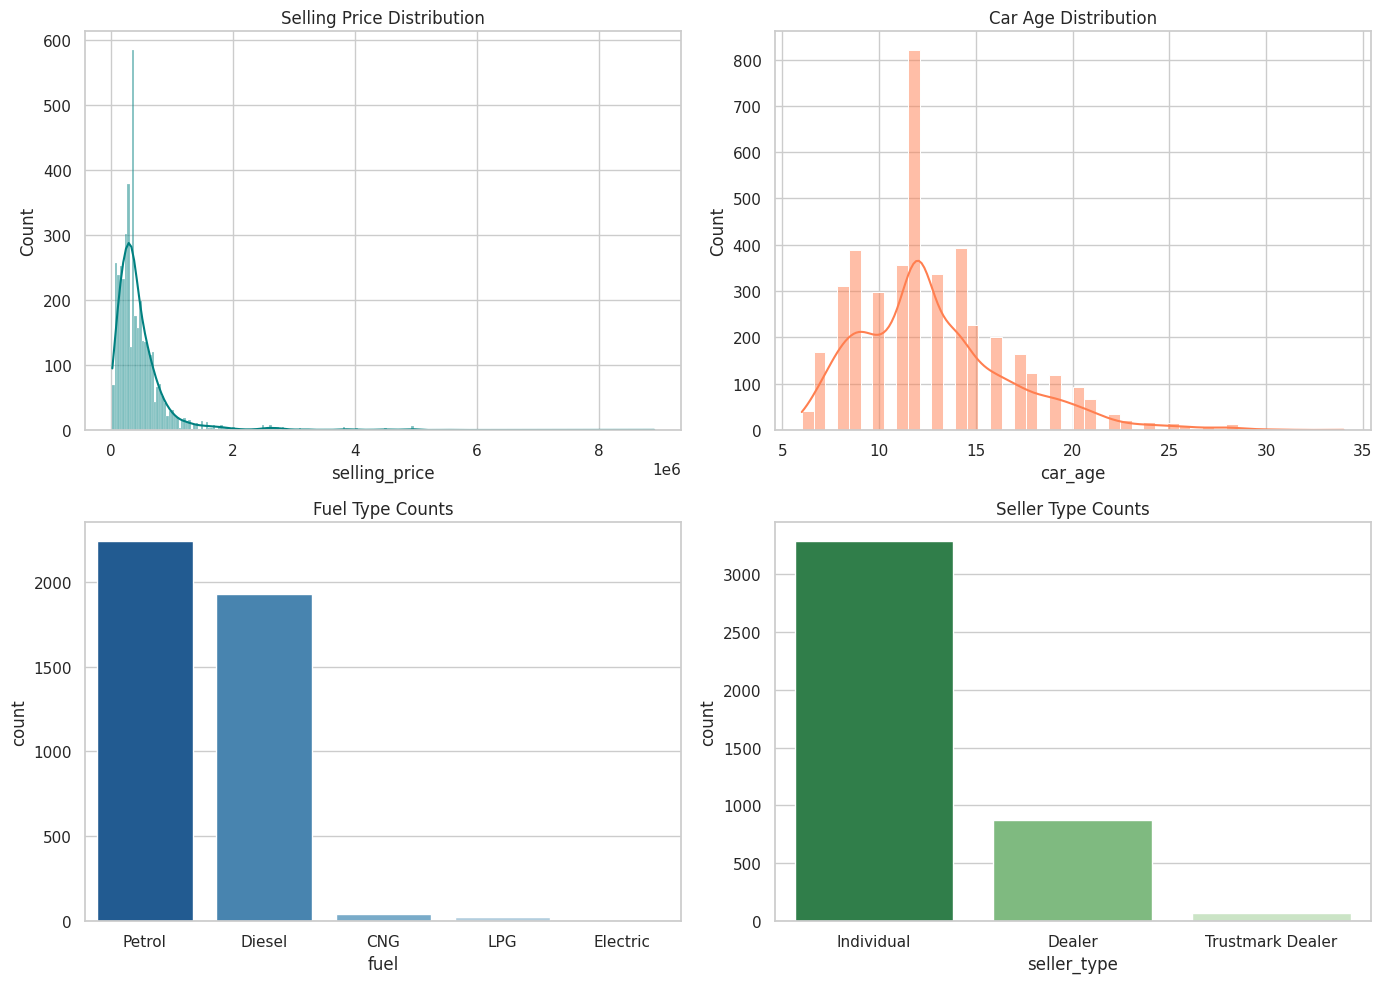

In [7]:
print("\n=== 4. UNIVARIATE ANALYSIS ===")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['selling_price'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Selling Price Distribution')

sns.histplot(df['car_age'], kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Car Age Distribution')

sns.countplot(x='fuel', data=df, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Fuel Type Counts')

sns.countplot(x='seller_type', data=df, ax=axes[1, 1], palette='Greens_r')
axes[1, 1].set_title('Seller Type Counts')

plt.tight_layout()
plt.savefig('univariate_analysis.png')

# **Bivariate Analysis**


=== 5. BIVARIATE ANALYSIS ===


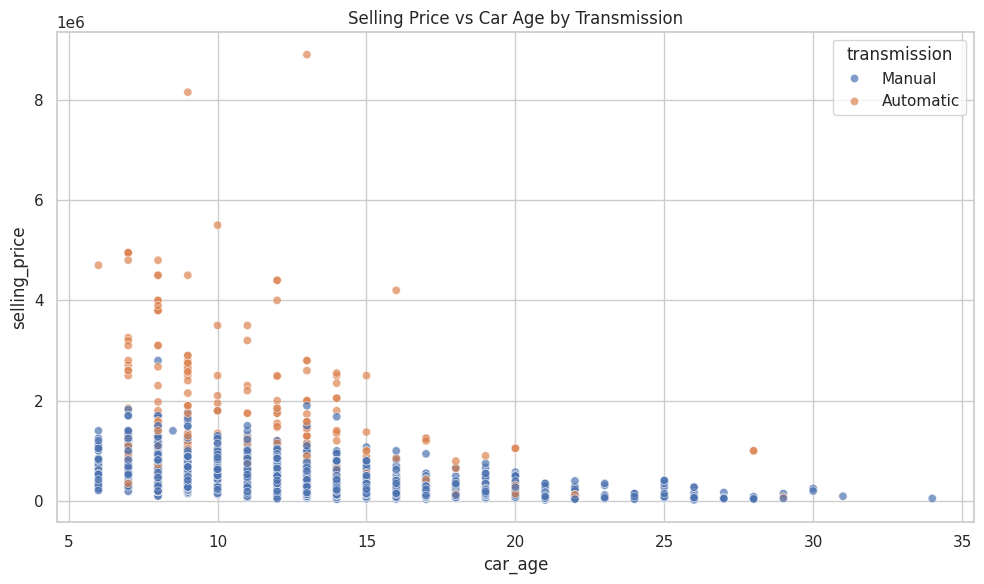

In [8]:
print("\n=== 5. BIVARIATE ANALYSIS ===")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='selling_price', hue='transmission', data=df, alpha=0.7)
plt.title('Selling Price vs Car Age by Transmission')
plt.tight_layout()
plt.savefig('bivariate_analysis.png')


# **Multivariate Analysis**

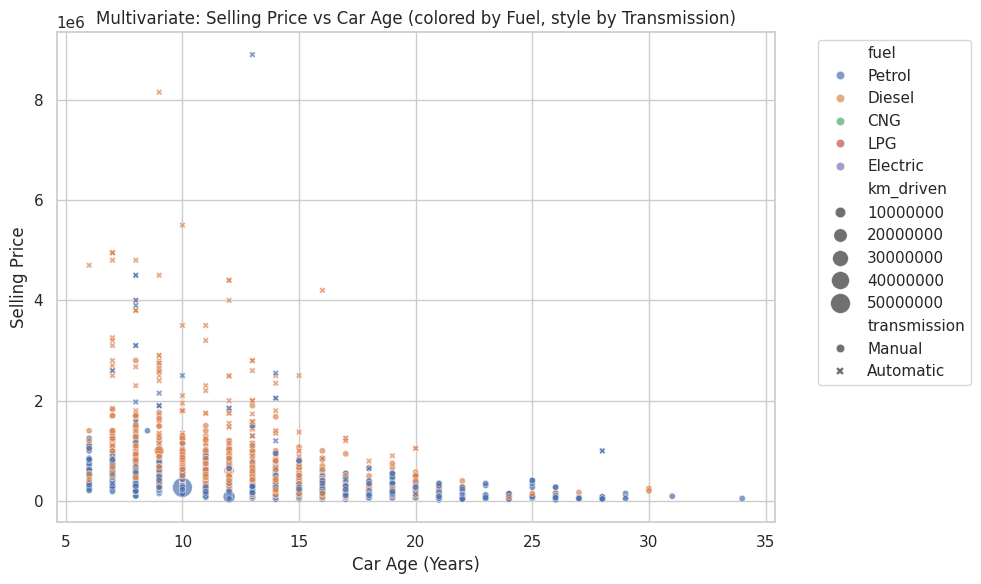

In [9]:
# Multivariate Plot 1: 4-Variable Analysis (Price vs Age vs Fuel vs Transmission)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price',
    hue='fuel',
    style='transmission',
    size='km_driven',
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Multivariate: Selling Price vs Car Age (colored by Fuel, style by Transmission)')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('multivariate_scatter.png')

# **Correlation Heatmap**

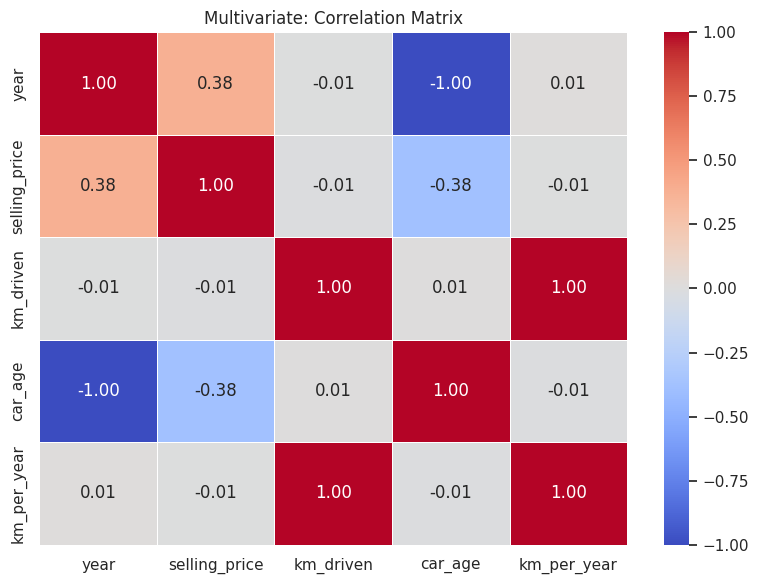

In [10]:
plt.figure(figsize=(8, 6))
num_cols = ['year', 'selling_price', 'km_driven', 'car_age', 'km_per_year']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Multivariate: Correlation Matrix')
plt.tight_layout()
plt.savefig('multivariate_heatmap.png')

# **Pair Plot**

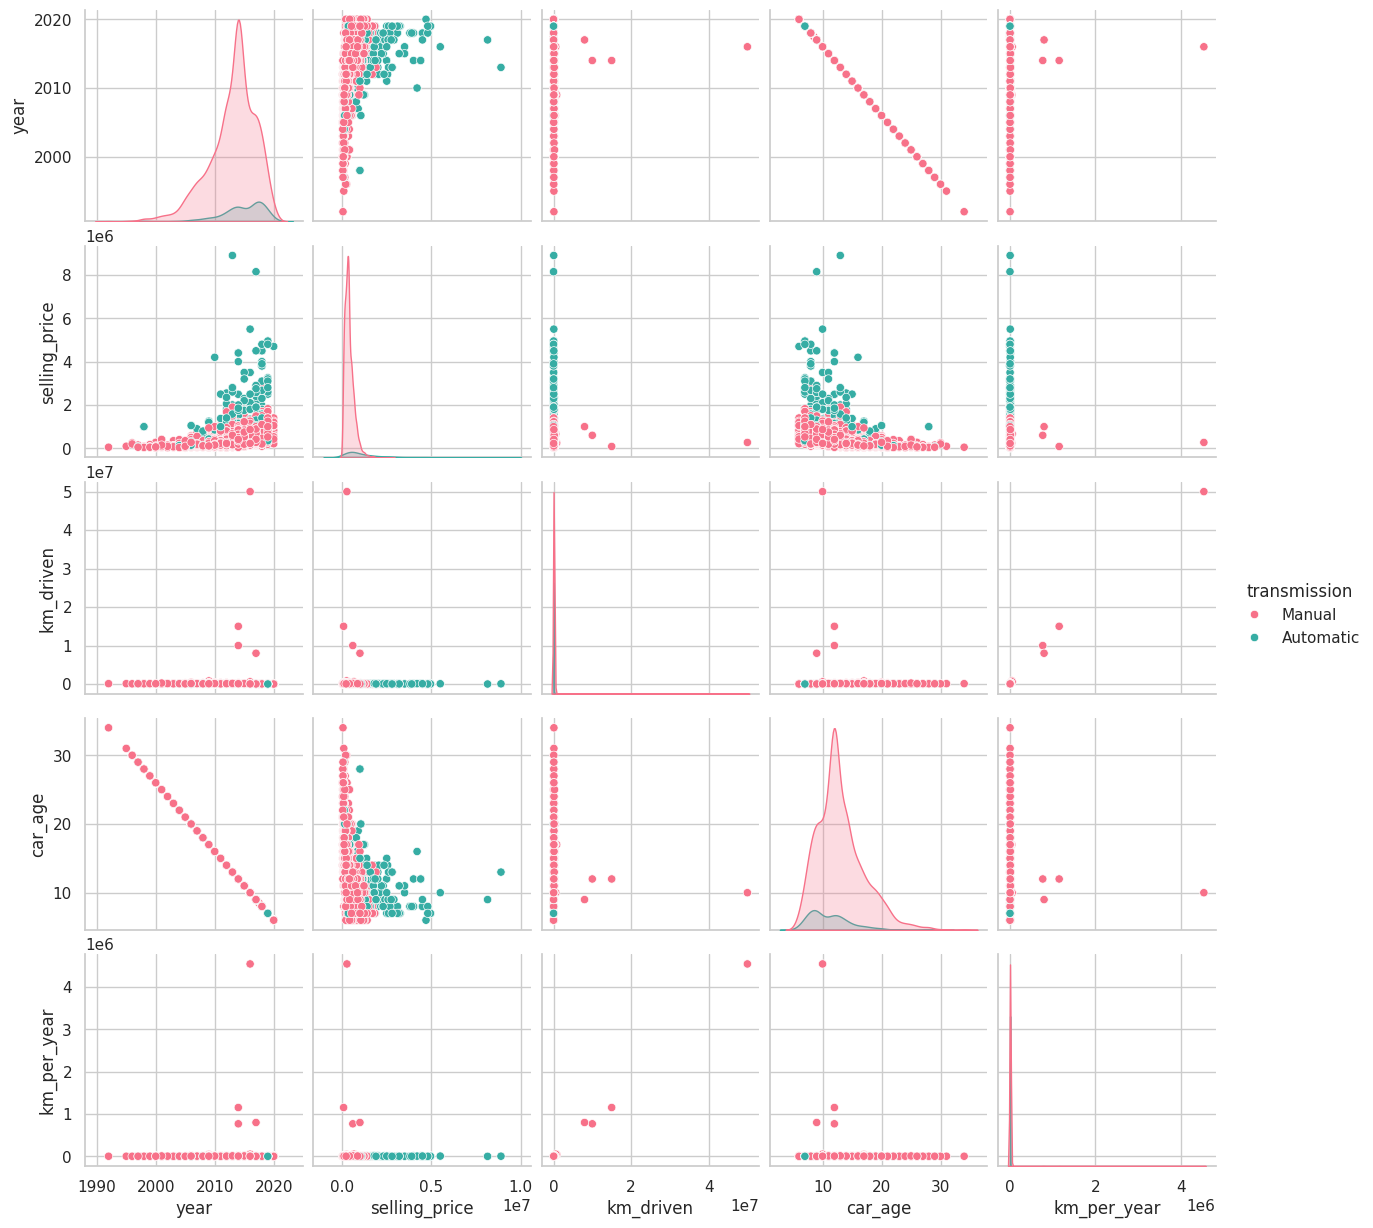

In [11]:
sns.pairplot(df[num_cols + ['transmission']], hue='transmission', palette='husl')
plt.savefig('multivariate_pairplot.png')

plt.show()

# **Final Insights**

### **Key Insights from Car Data Analysis**

**1. Data Inspection & Cleaning:**
- Initial inspection revealed missing values across several columns (`name`, `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`) and duplicate rows.
- Data cleaning involved removing duplicate entries, standardizing categorical typos (e.g., 'Petrrol' to 'Petrol'), and cleaning the `km_driven` column by removing text and converting to numerical format.
- Invalid outliers in `year` (before 1990 or after 2026) and `selling_price` (zero or negative) were handled by replacing them with `NaN`.
- Missing numerical values (`year`, `selling_price`, `km_driven`) were intelligently imputed using the median based on the car `brand`.
- Missing categorical values (`fuel`, `seller_type`, `transmission`, `owner`) were imputed using the mode.

**2. Feature Engineering:**
- Two new features were created:
    - `car_age`: Calculated as `2026 - year`, representing the age of the car.
    - `km_per_year`: Calculated as `km_driven / (car_age + 1)`, representing the average kilometers driven per year.
- `price_category` was created by quantiling `selling_price` into 'Budget', 'Mid-Range', and 'Luxury' to categorize cars based on price.

**3. Univariate Analysis Findings:**
- **Selling Price Distribution:** Heavily right-skewed, indicating that most cars are sold at lower prices, with a few high-priced outliers.
- **Car Age Distribution:** Shows a peak for cars around 10-15 years old, suggesting a common selling age range.
- **Fuel Type Counts:** Petrol and Diesel cars dominate the market, with CNG, LPG, and Electric cars being significantly less common.
- **Seller Type Counts:** Individual sellers make up the majority of the market, followed by Dealer sales, with Trustmark Dealers being a small segment.

**4. Bivariate Analysis Findings:**
- **Selling Price vs. Car Age by Transmission:** Generally, as car age increases, selling price tends to decrease. Manual transmission cars appear to be more numerous across all ages, while automatic transmission cars, particularly newer ones, command higher prices.

**5. Multivariate Analysis Findings:**
- **Selling Price vs. Car Age vs. Fuel vs. Transmission vs. Mileage (Scatter Plot):** This plot reinforced that newer, lower-mileage cars (larger points) tend to have higher selling prices. Fuel type and transmission also show clusters, with diesel cars often appearing at higher prices and older ages compared to petrol, and automatics potentially having higher prices.
- **Correlation Matrix:**
    - `year` and `car_age` are perfectly negatively correlated, as expected.
    - `selling_price` has a positive correlation with `year` (0.38) and a negative correlation with `car_age` (-0.38), indicating newer cars sell for more.
    - `km_driven` shows very little correlation with `selling_price`.
    - `km_per_year` is highly correlated with `km_driven` (0.99) but has a weak negative correlation with `selling_price`.
- **Pair Plot:** The pair plots provide a comprehensive view of relationships between all numerical variables, further highlighting the inverse relationship between car age/year and selling price, and the distributions of each variable by transmission type.

In [17]:
print("\n=== Average Selling Price by Brand ===")
average_price_by_brand = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).reset_index()
display(average_price_by_brand)


=== Average Selling Price by Brand ===


,brand,selling_price
0,Land,3.609800e+06
1,Mercedes-Benz,2.724385e+06
2,BMW,2.717353e+06
3,Volvo,2.556250e+06
4,Jaguar,2.090000e+06
5,Audi,2.027804e+06
6,MG,1.825000e+06
7,Jeep,1.530000e+06
8,Isuzu,1.500000e+06
9,Kia,1.300000e+06


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=average_price_by_brand)

https://docs.google.com/spreadsheets/d/1wbK8R8ZE7lMOAwlLaLtp3om6GoMRXlbHYoIacOHu64k/edit#gid=0


/tmp/ipykernel_3388/3251114608.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




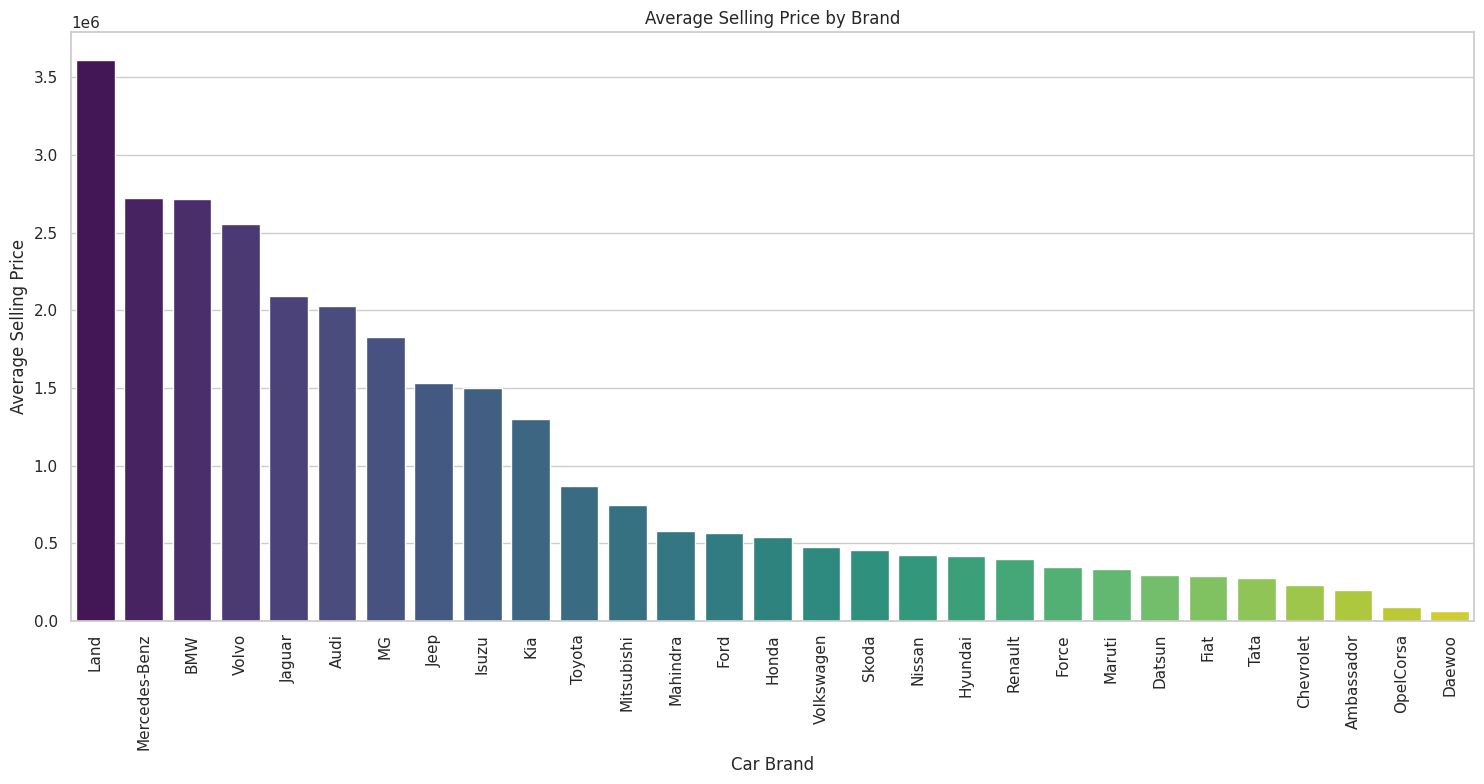

In [18]:
plt.figure(figsize=(15, 8))
sns.barplot(x='brand', y='selling_price', data=average_price_by_brand, palette='viridis')
plt.title('Average Selling Price by Brand')
plt.xlabel('Car Brand')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# **Dashboard**

In [13]:
! pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.1 MB/s eta 0:00:00


In [15]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Car Sales Analytics Dashboard", layout="wide")

st.title("🚗 Used Car Market Analytics Dashboard")
st.markdown("Interactive EDA dashboard featuring Univariate, Bivariate, and Multivariate analysis.")

@st.cache_data
def load_data():
    return pd.read_csv('cleaned_car_data.csv')

df = load_data()

# Sidebar Filters
st.sidebar.header("Filter Data")
brand_list = ["All"] + sorted(df['brand'].astype(str).unique().tolist())
selected_brand = st.sidebar.selectbox("Select Brand", brand_list)

fuel_list = ["All"] + sorted(df['fuel'].unique().tolist())
selected_fuel = st.sidebar.selectbox("Select Fuel Type", fuel_list)

transmission_list = ["All"] + sorted(df['transmission'].unique().tolist())
selected_trans = st.sidebar.selectbox("Select Transmission", transmission_list)

# Apply Filters
filtered_df = df.copy()
if selected_brand != "All":
    filtered_df = filtered_df[filtered_df['brand'] == selected_brand]
if selected_fuel != "All":
    filtered_df = filtered_df[filtered_df['fuel'] == selected_fuel]
if selected_trans != "All":
    filtered_df = filtered_df[filtered_df['transmission'] == selected_trans]

# Top Metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Cars", f"{len(filtered_df):,}")
col2.metric("Avg Selling Price", f"${filtered_df['selling_price'].mean():,.0f}")
col3.metric("Avg Mileage (KM)", f"{filtered_df['km_driven'].mean():,.0f} km")
col4.metric("Avg Car Age", f"{filtered_df['car_age'].mean():.1f} yrs")

st.markdown("---")

# Visualizations Tab Setup
tab1, tab2 = st.tabs(["📊 Overview & Bivariate", "🌐 Multivariate Analysis"])

with tab1:
    c1, c2 = st.columns(2)
    with c1:
        fig_price = px.histogram(filtered_df, x="selling_price", nbins=40, title="Univariate: Selling Price Distribution", color_discrete_sequence=['#008080'])
        st.plotly_chart(fig_price, use_container_width=True)
    with c2:
        fig_box = px.box(filtered_df, x="transmission", y="selling_price", color="transmission", title="Bivariate: Price by Transmission")
        st.plotly_chart(fig_box, use_container_width=True)

with tab2:
    st.subheader("Multivariate Feature Interaction")
    fig_multi = px.scatter(
        filtered_df,
        x="car_age",
        y="selling_price",
        color="fuel",
        symbol="transmission",
        size="km_driven",
        hover_data=['name', 'brand'],
        title="Multivariate: Price vs Car Age vs Fuel vs Transmission vs Mileage"
    )
    st.plotly_chart(fig_multi, use_container_width=True)

    st.subheader("Multivariate Numerical Correlation Matrix")
    num_cols = ['year', 'selling_price', 'km_driven', 'car_age', 'km_per_year']
    corr_df = filtered_df[num_cols].corr()
    fig_corr = px.imshow(corr_df, text_auto=True, color_continuous_scale='RdBu_r', title="Correlation Matrix Heatmap")
    st.plotly_chart(fig_corr, use_container_width=True)

if st.checkbox("Show Raw Data Table"):
    st.dataframe(filtered_df)

2026-09-09 20:19:35.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:19:35.575 No runtime found, using MemoryCacheStorageManager
2026-09-09 20:19:35.580 Thread 'MainThread':